# Model B: Budget Optimization (DNN Regressor)

**Fitur**: Memprediksi alokasi anggaran optimal per kategori pengeluaran.

**Model**: Dense Neural Network (Regressor) — TensorFlow/Keras

**Metode**: Supervised Learning — Regression dengan Softmax output

**Pipeline**:
1. Genetic Algorithm sebagai **data generator** untuk membuat training data (profil user → alokasi optimal)
2. DNN dilatih untuk mempelajari pola tersebut
3. Model DNN yang di-deploy (`.keras`), bukan GA

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os, pickle, datetime

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}, Keras: {keras.__version__}')

TensorFlow: 2.21.0, Keras: 3.14.0


## 1. Load Data & Analisis Pola Aktual

In [2]:
df = pd.read_csv('alice_transactions_final.csv')
df['date'] = pd.to_datetime(df['date'])

CATEGORIES = sorted(df['category'].unique().tolist())
ESSENTIAL = ['Bills', 'Food & Beverage', 'Transport']
IMPULSIVE = ['Entertainment', 'Hobby', 'Shopping']
N_CATS = len(CATEGORIES)
N_OUTPUT = N_CATS + 1  # 7 kategori + 1 savings
LABELS = CATEGORIES + ['Savings']

essential_idx = [CATEGORIES.index(c) for c in ESSENTIAL]
impulsive_idx = [CATEGORIES.index(c) for c in IMPULSIVE]

print(f'Kategori: {CATEGORIES}')
print(f'Output: {LABELS}')

Kategori: ['Bills', 'Entertainment', 'Food & Beverage', 'Hobby', 'Shopping', 'Subscriptions', 'Transport']
Output: ['Bills', 'Entertainment', 'Food & Beverage', 'Hobby', 'Shopping', 'Subscriptions', 'Transport', 'Savings']


In [3]:
# Buat profil spending per user
user_profiles = []
for uid, grp in df.groupby('user_id'):
    cat_spending = grp.groupby('category')['amount'].sum()
    total = cat_spending.sum()
    props = [cat_spending.get(c, 0) / total for c in CATEGORIES]
    income = grp['monthly_income'].iloc[0]
    budget = grp['weekly_budget_limit'].iloc[0]
    user_profiles.append(props + [income, budget])

user_profiles = np.array(user_profiles, dtype=np.float32)
print(f'User profiles shape: {user_profiles.shape}')
print(f'Kolom: 7 proporsi kategori + income + budget')

User profiles shape: (1000, 9)
Kolom: 7 proporsi kategori + income + budget


## 2. Genetic Algorithm — Generate Training Data

GA digunakan sebagai **data generator** untuk membuat pasangan (profil_user → alokasi_optimal).

In [4]:
# === GA Functions ===
MIN_ESSENTIAL = 0.55
MAX_IMPULSIVE = 0.30
MIN_SAVINGS = 0.10

def repair(chrom):
    chrom = np.abs(chrom)
    chrom /= chrom.sum()
    if chrom[-1] < MIN_SAVINGS:
        chrom[-1] = MIN_SAVINGS
        chrom[:-1] *= (1 - MIN_SAVINGS) / max(chrom[:-1].sum(), 1e-8)
    ess = chrom[essential_idx].sum()
    if ess < MIN_ESSENTIAL:
        chrom[essential_idx] *= MIN_ESSENTIAL / max(ess, 1e-8)
        chrom /= chrom.sum()
    imp = chrom[impulsive_idx].sum()
    if imp > MAX_IMPULSIVE:
        chrom[impulsive_idx] *= MAX_IMPULSIVE / imp
        chrom /= chrom.sum()
    return chrom

def fitness(chrom):
    sav = chrom[-1]
    ess = min(chrom[essential_idx].sum() / MIN_ESSENTIAL, 1.0)
    imp_pen = max(0, (chrom[impulsive_idx].sum() - MAX_IMPULSIVE) * 5)
    sav_pen = max(0, (MIN_SAVINGS - sav) * 10)
    return max(sav * 0.6 + ess * 0.4 - imp_pen - sav_pen, 0.0)

def run_ga_for_profile(profile, pop_size=80, gens=150):
    """Jalankan GA untuk satu profil user, return alokasi optimal."""
    pop = np.array([repair(np.random.dirichlet(np.ones(N_OUTPUT))) for _ in range(pop_size)])
    for _ in range(gens):
        fits = np.array([fitness(ind) for ind in pop])
        new_pop = [pop[np.argmax(fits)].copy()]
        while len(new_pop) < pop_size:
            # Tournament
            idx = np.random.choice(pop_size, 5, replace=False)
            p1 = pop[idx[np.argmax(fits[idx])]].copy()
            idx = np.random.choice(pop_size, 5, replace=False)
            p2 = pop[idx[np.argmax(fits[idx])]].copy()
            # Crossover
            mask = np.random.random(N_OUTPUT) < 0.5
            c = p1.copy(); c[mask] = p2[mask]
            # Mutation
            if np.random.random() < 0.1:
                c[np.random.randint(N_OUTPUT)] += np.random.uniform(-0.05, 0.05)
            new_pop.append(repair(c))
        pop = np.array(new_pop[:pop_size])
    fits = np.array([fitness(ind) for ind in pop])
    return pop[np.argmax(fits)]

print('GA functions ready.')

GA functions ready.


In [5]:
# Generate training data: untuk setiap user, GA cari alokasi optimal
print('Generating optimal allocations via GA... (ini memakan waktu beberapa menit)')
X_ga = []
y_ga = []

for i, profile in enumerate(user_profiles):
    optimal = run_ga_for_profile(profile)
    X_ga.append(profile)
    y_ga.append(optimal)
    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(user_profiles)} user selesai')

# Augmentasi: tambah variasi noise pada profil untuk memperbanyak data
for i in range(len(user_profiles)):
    for _ in range(4):  # 4x augmentasi
        noisy = user_profiles[i].copy()
        noisy[:N_CATS] += np.random.normal(0, 0.02, N_CATS)
        noisy[:N_CATS] = np.clip(noisy[:N_CATS], 0, 1)
        noisy[:N_CATS] /= noisy[:N_CATS].sum()
        X_ga.append(noisy)
        y_ga.append(y_ga[i])  # Same optimal allocation

X_ga = np.array(X_ga, dtype=np.float32)
y_ga = np.array(y_ga, dtype=np.float32)
print(f'\nTraining data: X={X_ga.shape}, y={y_ga.shape}')

Generating optimal allocations via GA... (ini memakan waktu beberapa menit)
  100/1000 user selesai
  200/1000 user selesai
  300/1000 user selesai
  400/1000 user selesai
  500/1000 user selesai
  600/1000 user selesai
  700/1000 user selesai
  800/1000 user selesai
  900/1000 user selesai
  1000/1000 user selesai

Training data: X=(5000, 9), y=(5000, 8)


## 3. DNN Regressor — Arsitektur & Training

In [6]:
# Normalize input
input_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(X_ga).astype(np.float32)

# Split
split = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_ga[:split], y_ga[split:]

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(512).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (4000, 9), Test: (1000, 9)


In [7]:
@keras.saving.register_keras_serializable()
class BudgetOptimizer(keras.Model):
    """DNN yang memprediksi alokasi budget optimal (softmax output)."""
    def __init__(self, n_output=N_OUTPUT, **kwargs):
        super().__init__(**kwargs)
        self.n_output = n_output
        self.dense1 = keras.layers.Dense(64, activation='relu')
        self.bn1 = keras.layers.BatchNormalization()
        self.dropout1 = keras.layers.Dropout(0.2)
        self.dense2 = keras.layers.Dense(128, activation='relu')
        self.bn2 = keras.layers.BatchNormalization()
        self.dropout2 = keras.layers.Dropout(0.2)
        self.dense3 = keras.layers.Dense(64, activation='relu')
        self.output_layer = keras.layers.Dense(n_output, activation='softmax')

    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)
        x = self.dropout2(x, training=training)
        x = self.dense3(x)
        return self.output_layer(x)

    def get_config(self):
        config = super().get_config()
        config.update({'n_output': self.n_output})
        return config

budget_model = BudgetOptimizer()
budget_model(tf.zeros((1, X_train.shape[1])))
budget_model.summary()

Model: "budget_optimizer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 64)                │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 64)                │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 128)               │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 128)               │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 8)                 │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,504 (72.28 KB)

 Trainable params: 18,120 (70.78 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
# === Custom Training Loop (tf.GradientTape) ===
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss_fn = keras.losses.MeanSquaredError()
train_loss = keras.metrics.Mean()
val_loss = keras.metrics.Mean()

log_dir = os.path.join('logs', 'budget_opt', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
train_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'train'))
val_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'validation'))

EPOCHS = 100
history = {'train_loss': [], 'val_loss': []}

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        pred = budget_model(x, training=True)
        loss = loss_fn(y, pred)
    grads = tape.gradient(loss, budget_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, budget_model.trainable_variables))
    train_loss.update_state(loss)

@tf.function
def val_step(x, y):
    pred = budget_model(x, training=False)
    val_loss.update_state(loss_fn(y, pred))

for epoch in range(EPOCHS):
    train_loss.reset_state()
    val_loss.reset_state()
    for x, y in train_ds:
        train_step(x, y)
    for x, y in test_ds:
        val_step(x, y)
    
    tl = train_loss.result().numpy()
    vl = val_loss.result().numpy()
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    
    with train_writer.as_default():
        tf.summary.scalar('loss', tl, step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('loss', vl, step=epoch)
    
    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {tl:.6f} | Val Loss: {vl:.6f}')

print('Training selesai!')

Epoch  20/100 | Train Loss: 0.006090 | Val Loss: 0.006684
Epoch  40/100 | Train Loss: 0.005815 | Val Loss: 0.006739
Epoch  60/100 | Train Loss: 0.005556 | Val Loss: 0.006901
Epoch  80/100 | Train Loss: 0.005370 | Val Loss: 0.006780
Epoch 100/100 | Train Loss: 0.005298 | Val Loss: 0.006847
Training selesai!


## 4. Evaluasi & Visualisasi

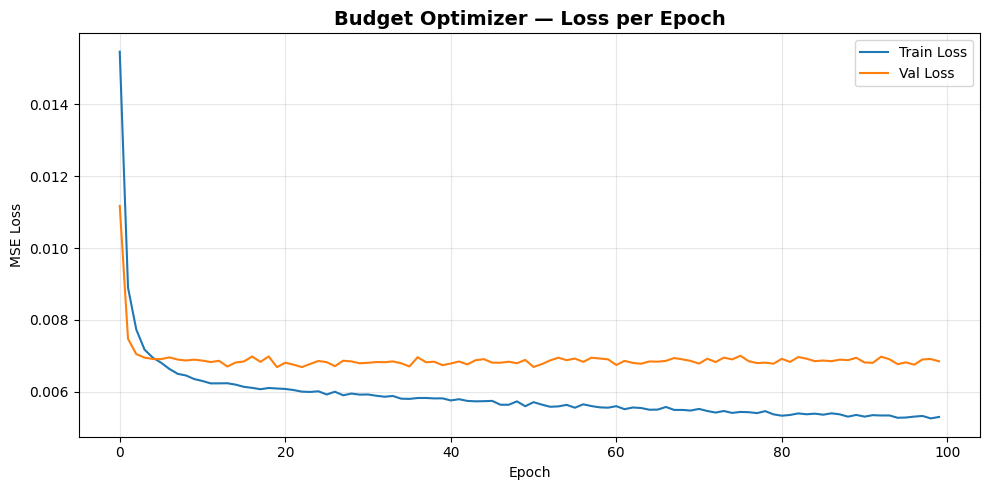

In [9]:
# Loss plot
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Budget Optimizer — Loss per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# Demo: prediksi untuk sample user
sample_idx = 0
sample_input = X_scaled[sample_idx:sample_idx+1]
pred = budget_model.predict(sample_input, verbose=0)[0]
actual_props = np.append(user_profiles[sample_idx][:N_CATS], 0.0)  # Aktual (tanpa savings)

avg_budget = df['weekly_budget_limit'].mean()

print('=== Rekomendasi Alokasi Budget ===')
print(f'{"Kategori":20s} | {"Aktual":>8s} | {"Optimal":>8s} | {"Rp/Minggu":>12s}')
print('-' * 60)
for i, label in enumerate(LABELS):
    act = actual_props[i] * 100 if i < len(actual_props) else 0
    opt = pred[i] * 100
    rp = avg_budget * pred[i]
    print(f'{label:20s} | {act:7.1f}% | {opt:7.1f}% | Rp {rp:>10,.0f}')

print(f'\nPotensi tabungan per bulan: Rp {avg_budget * pred[-1] * 4:,.0f}')

=== Rekomendasi Alokasi Budget ===
Kategori             |   Aktual |  Optimal |    Rp/Minggu
------------------------------------------------------------
Bills                |     4.4% |    13.6% | Rp    106,582
Entertainment        |    38.5% |     0.1% | Rp        417
Food & Beverage      |    13.3% |    16.8% | Rp    131,493
Hobby                |    11.9% |     0.1% | Rp        491
Shopping             |    15.8% |     0.1% | Rp        396
Subscriptions        |     4.8% |     0.1% | Rp        464
Transport            |    11.3% |    25.4% | Rp    199,314
Savings              |     0.0% |    44.0% | Rp    345,142

Potensi tabungan per bulan: Rp 1,380,568


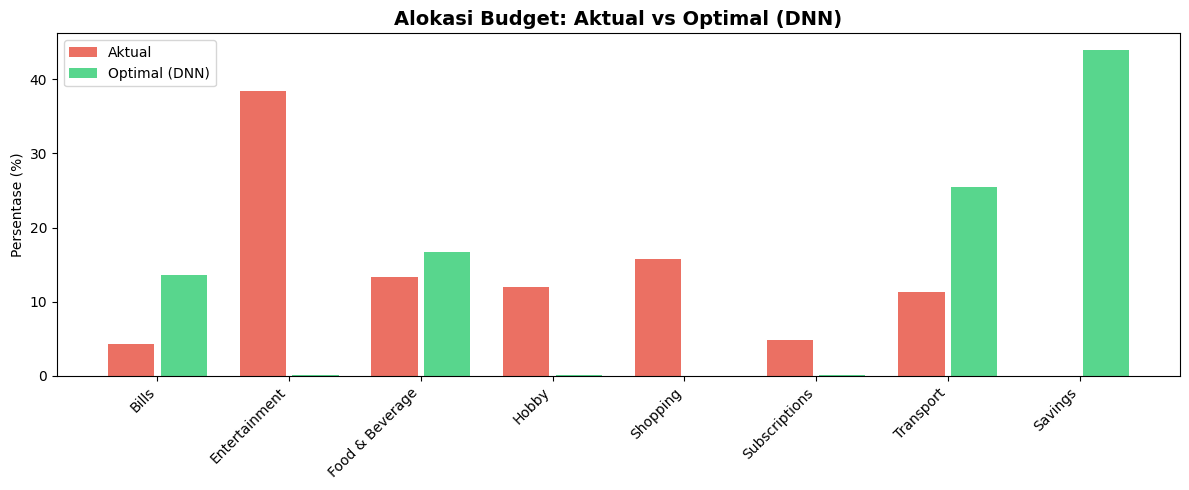

In [11]:
# Bar chart perbandingan
x = np.arange(len(LABELS))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, actual_props * 100, 0.35, label='Aktual', color='#e74c3c', alpha=0.8)
ax.bar(x + 0.2, pred * 100, 0.35, label='Optimal (DNN)', color='#2ecc71', alpha=0.8)
ax.set_title('Alokasi Budget: Aktual vs Optimal (DNN)', fontsize=14, fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=45, ha='right')
ax.legend()
plt.tight_layout(); plt.show()

## 5. Save Model

In [12]:
os.makedirs('models/saved', exist_ok=True)
budget_model.save('models/saved/budget_model.keras')
with open('models/saved/budget_scaler.pkl', 'wb') as f:
    pickle.dump(input_scaler, f)
print('Model disimpan: models/saved/budget_model.keras')
print('Scaler disimpan: models/saved/budget_scaler.pkl')

Model disimpan: models/saved/budget_model.keras
Scaler disimpan: models/saved/budget_scaler.pkl


## Insight

DNN Budget Optimizer mempelajari pola dari Genetic Algorithm untuk menghasilkan rekomendasi alokasi budget optimal secara **instan** (tanpa perlu menjalankan GA ulang).

Keunggulan dibanding GA murni:
- **Inference cepat**: `model.predict()` dalam milidetik vs GA yang butuh ratusan iterasi
- **Deployable**: Format `.keras` siap di-wrap dengan FastAPI
- **Consistent API**: Sama seperti model LSTM, pakai `model.predict()`